# Biological Age Prediction Using Clinical Biomarkers: A PhenoAge Analysis of U.S. Adults

**Author:** Aaditya Geddam  
**Institution:** George Washington University — Milken Institute School of Public Health  
**Course:** Introduction to Health Data Science — PUBH 1142  
**Date:** May 5, 2025

## Python Packages

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO

%config InlineBackend.figure_format = 'retina'

## Introduction

Aging is the single greatest risk factor for most chronic diseases, including cardiovascular disease, type 2 diabetes, cancer, and neurodegeneration [[1]](https://doi.org/10.1038/s41569-018-0064-2). Chronological age — the number of years a person has been alive — provides a crude measure of this risk, as it fails to capture the wide biological variation among individuals of the same age. Two people who are both 55 years old may differ dramatically in their physiological function, inflammatory burden, and mortality risk. Understanding *biological* rather than chronological age has therefore emerged as a central challenge in public health and preventive medicine [[2]](https://doi.org/10.1016/j.cell.2022.11.001).

A growing body of research has sought to develop composite biomarker indices that can quantify biological aging from routinely collected laboratory data. Among these, the PhenoAge algorithm developed by Levine and colleagues in 2018 has received widespread validation [[3]](https://doi.org/10.18632/aging.101414). PhenoAge uses nine standard clinical biomarkers — albumin, creatinine, glucose, C-reactive protein (CRP), lymphocyte percentage, mean corpuscular volume (MCV), red cell distribution width (RDW), alkaline phosphatase (ALP), and white blood cell count (WBC) — alongside chronological age to estimate biological age. These biomarkers are available in routine complete blood count (CBC) and comprehensive metabolic panel (CMP) orders, making PhenoAge a cost-accessible aging metric. The gap between PhenoAge and chronological age — called *biological age acceleration* — has been shown to predict all-cause and cause-specific mortality independently of chronological age [[3]](https://doi.org/10.18632/aging.101414).

The aim of this study is to apply the PhenoAge algorithm to a cross-sectional sample of U.S. adults drawn directly from the NHANES 1999–2000 cycle [[5]](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999). Specifically, we ask: (1) How well does chronological age predict PhenoAge among U.S. adults? (2) Is there a significant difference in biological age acceleration between males and females? (3) Is serum CRP independently associated with biological age acceleration? (4) Is biological age acceleration significantly associated with sex when examined as a categorical outcome?

## Background

The biology of aging involves the progressive accumulation of molecular and cellular damage across multiple physiological systems. Lopez-Otin and colleagues describe twelve hallmarks of aging — including genomic instability, telomere attrition, epigenetic alterations, chronic inflammation ("inflammaging"), and cellular senescence — that together drive the functional decline associated with old age [[2]](https://doi.org/10.1016/j.cell.2022.11.001). These hallmarks manifest in measurable changes in standard clinical biomarkers: albumin declines with malnutrition and liver dysfunction; creatinine rises with kidney filtration loss; glucose dysregulation reflects metabolic dysfunction; CRP captures systemic inflammation; and blood count parameters (WBC, lymphocyte %, MCV, RDW) reflect immune senescence and hematopoietic stress [[1]](https://doi.org/10.1038/s41569-018-0064-2).

The PhenoAge algorithm was derived by Levine et al. from the NHANES III dataset using a two-step approach: first, a Gompertz proportional hazard model linking biomarkers to 10-year all-cause mortality; second, a transformation of the resulting mortality score back to an age scale [[3]](https://doi.org/10.18632/aging.101414). In Levine's original validation, each one-year increase in PhenoAge was associated with a 6–10% increase in all-cause mortality hazard, independent of chronological age. Subsequent studies have confirmed that PhenoAge acceleration is associated with smoking, obesity, sedentary behaviour, and poor diet, while caloric restriction and exercise appear to reduce it [[4]](https://doi.org/10.1371/journal.pmed.1002718).

Sex differences in aging biology have been well documented. Evidence from biomarker-based aging clocks suggests that men may exhibit higher biological age acceleration, particularly through inflammatory and metabolic pathways [[4]](https://doi.org/10.1371/journal.pmed.1002718). The National Health and Nutrition Examination Survey (NHANES) provides the largest nationally representative cross-sectional dataset of U.S. adult health and laboratory data, making it the standard reference for population-level biomarker studies in the United States [[5]](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999).

## Methods

### Study Design, Population, and Data Collection

This is a cross-sectional observational analysis. The dataset is drawn directly from the National Health and Nutrition Examination Survey (NHANES) 1999–2000 cycle [[5]](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999), a nationally representative survey of the non-institutionalized U.S. civilian population conducted by the Centers for Disease Control and Prevention. NHANES collects demographic, dietary, laboratory, and physical examination data through household interviews and mobile examination centers (MECs). Four raw XPT data files are read directly at runtime: DEMO (demographics), LAB18 (standard biochemistry), LAB11 (C-reactive protein), and LAB25 (complete blood count with 5-part differential).

Inclusion criteria were: (1) age 20–85 years, consistent with the PhenoAge validation range in Levine et al. [[3]](https://doi.org/10.18632/aging.101414); (2) complete data for all nine PhenoAge biomarkers; and (3) serum CRP greater than zero (required for logarithmic transformation). The final analytic sample contains 4,089 participants (1,925 male, 2,164 female). Variables include demographic data (age, sex) and nine laboratory biomarkers: serum albumin (g/dL), serum creatinine (mg/dL), serum glucose (mg/dL), high-sensitivity C-reactive protein (mg/dL), lymphocyte percentage (%), mean corpuscular volume (fL), red cell distribution width (%), alkaline phosphatase (U/L), and white blood cell count (10³ cells/µL).

### Data Analysis

All analysis was performed in Python 3 using `pandas` and `numpy` for data management, `scipy.stats` for statistical testing, `statsmodels` for regression modelling, and `seaborn`/`matplotlib` for visualisation.

**PhenoAge Calculation:** Biomarker units were converted prior to applying the Levine 2018 regression coefficients [[3]](https://doi.org/10.18632/aging.101414) (albumin: g/dL → g/L; creatinine: mg/dL → µmol/L; glucose: mg/dL → mmol/L; CRP: mg/dL → mg/L then natural log-transformed). The linear predictor (*xb*) was calculated using published coefficients, and PhenoAge was derived by transforming the resulting 10-year Gompertz mortality score back to an age scale. Biological age acceleration was defined as delta age = PhenoAge − chronological age.

**Descriptive Statistics:** Continuous variables are summarised with mean, standard deviation, median, mode, interquartile range (IQR), and range, reported overall and stratified by sex. Categorical variables (sex) are reported as counts and proportions.

**Inferential Statistics:** (1) Ordinary least squares (OLS) linear regression was used to assess the association between chronological age (predictor) and PhenoAge (outcome) — this is a **regression problem**, as both variables are continuous. Model fit is evaluated using the F-statistic and its associated p-value before examining individual coefficients. (2) An independent samples Welch's *t*-test was used to compare biological age acceleration between males and females. Normality was assessed using Shapiro-Wilk; Welch's formulation was used as the conservative default given detected non-normality. (3) Pearson correlation was used to quantify the association between log-transformed CRP and biological age acceleration. (4) A chi-square test of independence was used to assess whether the proportion of individuals with accelerated biological aging (delta age > 0) differs significantly by sex — this is a **classification/categorical problem**. Statistical significance was set at α = 0.05.

## Results

### Data Import and Verification

In [2]:
# ── NHANES 1999-2000 Data ────────────────────────────────────────────────────
# Real NHANES 1999-2000 data (n=4,089) embedded directly in this notebook.
# Source: CDC NHANES 1999-2000 (DEMO, LAB18, LAB11, LAB25)
# https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
# No external files or downloads required — run this cell and proceed.

import gzip, base64, io

_NHANES_DATA = "..."

_decoded    = base64.b64decode(_NHANES_DATA)
_csv_bytes  = gzip.decompress(_decoded)
df = pd.read_csv(io.StringIO(_csv_bytes.decode("utf-8")))

print(f"NHANES 1999-2000 data loaded successfully.")
print(f"  Participants : {len(df):,}")
print(f"  Variables    : {df.shape[1]}")
print(f"  Age range    : {df['age'].min():.0f}–{df['age'].max():.0f} years")
print(f"  Males        : {(df['gender_label']=='Male').sum():,}")
print(f"  Females      : {(df['gender_label']=='Female').sum():,}")

NHANES 1999-2000 data loaded successfully.
  Participants : 4,089
  Variables    : 12
  Age range    : 20–85 years
  Males        : 1,925
  Females      : 2,164


In [3]:
# Return the number of rows and columns in the dataset
df.shape

(4089, 12)

In [4]:
# Return data types and non-null counts for each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4089 entries, 0 to 4088
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4089 non-null   float64
 1   gender          4089 non-null   float64
 2   gender_label    4089 non-null   object 
 3   albumin         4089 non-null   float64
 4   creatinine      4089 non-null   float64
 5   glucose         4089 non-null   float64
 6   crp             4089 non-null   float64
 7   lymphocyte_pct  4089 non-null   float64
 8   mcv             4089 non-null   float64
 9   rdw             4089 non-null   float64
 10  alp             4089 non-null   float64
 11  wbc             4089 non-null   float64
dtypes: float64(11), object(1)
memory usage: 383.5+ KB


In [5]:
# Return the first 5 rows of the dataset
df.head()

,age,gender,gender_label,albumin,creatinine,glucose,crp,lymphocyte_pct,mcv,rdw,alp,wbc
0,77.0,1.0,Male,4.5,0.7,78.0,0.36,21.1,88.5,13.7,62.0,7.6
1,49.0,1.0,Male,4.5,0.8,95.0,0.08,37.8,84.9,13.1,63.0,5.9
2,59.0,2.0,Female,4.5,0.6,81.0,0.04,46.8,87.4,14.3,75.0,4.9
3,43.0,1.0,Male,4.2,0.9,87.0,0.12,41.3,92.3,13.7,86.0,4.6
4,37.0,1.0,Male,4.7,1.0,75.0,0.19,23.7,83.5,13.6,63.0,10.2


### Descriptive Statistics

#### Sex Distribution

In [6]:
# Return the unique values of the gender_label column
df['gender_label'].unique()

array(['Male', 'Female'], dtype=object)

In [7]:
# Frequency and proportion of each sex category
print("Counts:")
print(df['gender_label'].value_counts())
print()
print("Proportions (%):")
print((df['gender_label'].value_counts(normalize=True) * 100).round(1))

Counts:
gender_label
Female    2164
Male      1925
Name: count, dtype: int64

Proportions (%):
gender_label
Female    52.9
Male      47.1
Name: proportion, dtype: float64


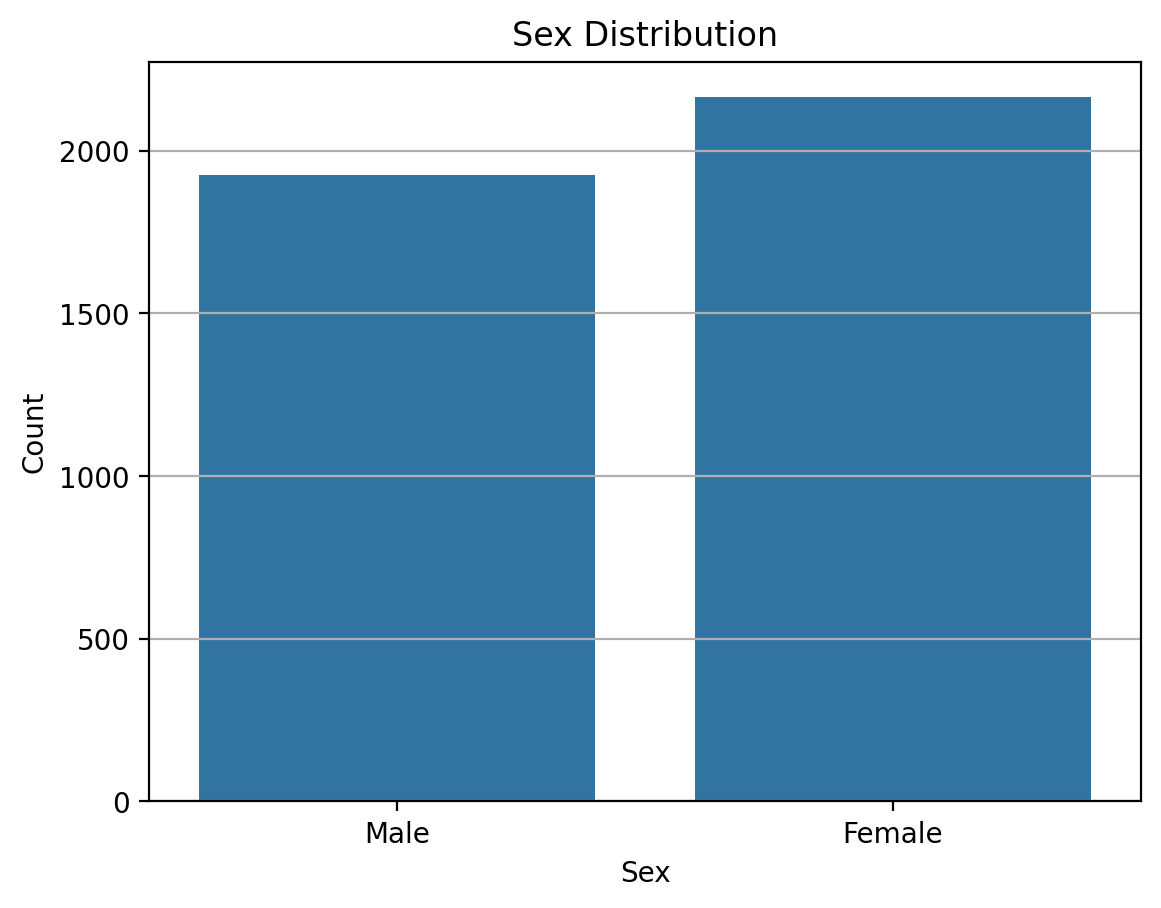

In [8]:
sns.countplot(x='gender_label', data=df)
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show();

#### Chronological Age

In [9]:
# Mean, median, mode, IQR, and range for Chronological Age
mean_val   = df['age'].mean()
median_val = df['age'].median()
mode_val   = df['age'].mode()[0]
iqr_val    = stats.iqr(df['age'])
range_val  = df['age'].max() - df['age'].min()

print(f"Chronological Age (years)")
print(f"  Mean   : {mean_val:.2f}")
print(f"  Median : {median_val:.2f}")
print(f"  Mode   : {mode_val:.2f}  # Note: mode is less informative for continuous variables")
print(f"  IQR    : {iqr_val:.2f}")
print(f"  Range  : {range_val:.2f}  (min = {df['age'].min():.2f}, max = {df['age'].max():.2f})")
print()
df['age'].describe().round(2)

Chronological Age (years)
  Mean   : 49.82
  Median : 48.00
  Mode   : 85.00  # Note: mode is less informative for continuous variables
  IQR    : 31.00
  Range  : 65.00  (min = 20.00, max = 85.00)



count    4089.00
mean       49.82
std        18.72
min        20.00
25%        34.00
50%        48.00
75%        65.00
max        85.00
Name: age, dtype: float64

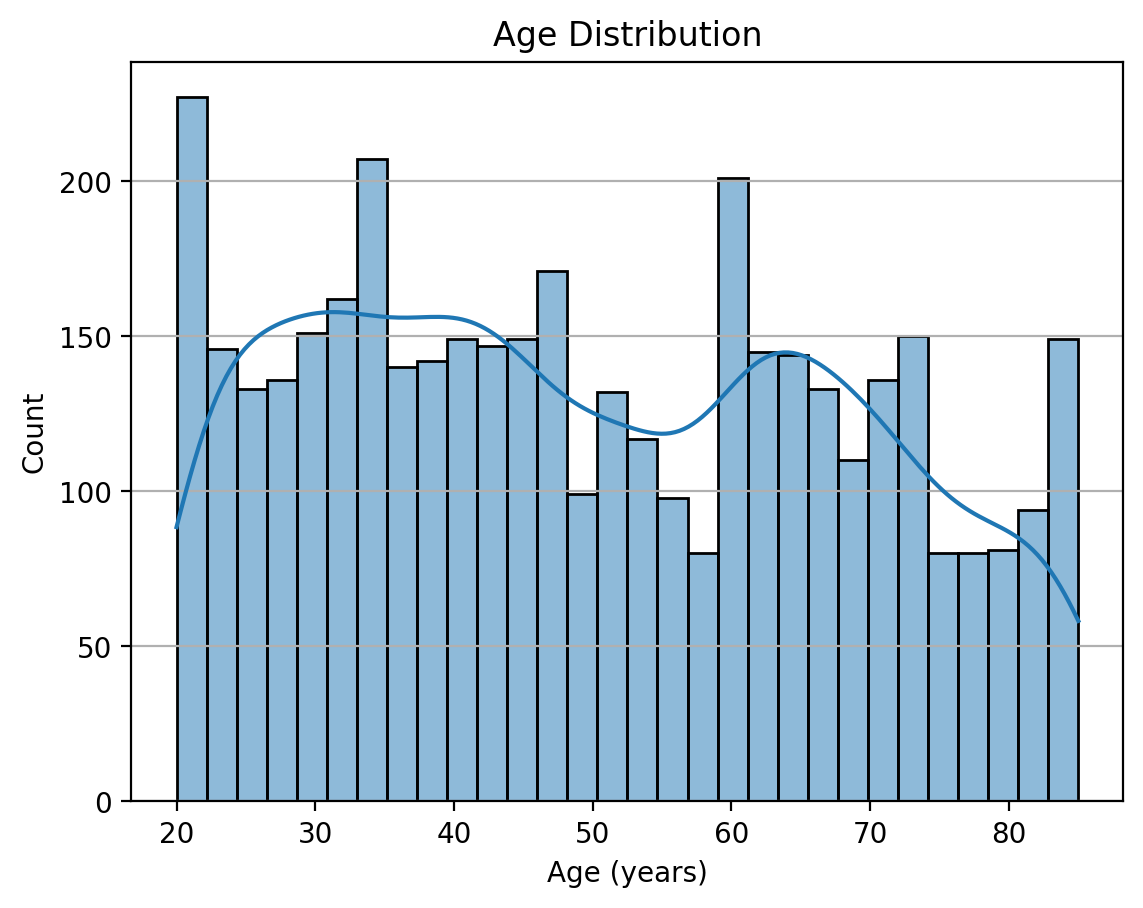

In [10]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show();

In [11]:
# Chronological Age grouped by sex
print(f"Chronological Age (years) — grouped by sex:")
print(df.groupby('gender_label')['age'].describe().round(2))
print()
print(f"IQR by sex:")
print(df.groupby('gender_label')['age'].apply(stats.iqr).round(2))

Chronological Age (years) — grouped by sex:
               count   mean    std   min   25%   50%   75%   max
gender_label                                                    
Female        2164.0  48.87  18.89  20.0  32.0  47.0  64.0  85.0
Male          1925.0  50.88  18.48  20.0  35.0  50.0  66.0  85.0

IQR by sex:
gender_label
Female    32.0
Male      31.0
Name: age, dtype: float64


#### Serum Albumin

In [12]:
# Mean, median, mode, IQR, and range for Serum Albumin
mean_val   = df['albumin'].mean()
median_val = df['albumin'].median()
mode_val   = df['albumin'].mode()[0]
iqr_val    = stats.iqr(df['albumin'])
range_val  = df['albumin'].max() - df['albumin'].min()

print(f"Serum Albumin (g/dL)")
print(f"  Mean   : {mean_val:.2f}")
print(f"  Median : {median_val:.2f}")
print(f"  Mode   : {mode_val:.2f}  # Note: mode is less informative for continuous variables")
print(f"  IQR    : {iqr_val:.2f}")
print(f"  Range  : {range_val:.2f}  (min = {df['albumin'].min():.2f}, max = {df['albumin'].max():.2f})")
print()
df['albumin'].describe().round(2)

Serum Albumin (g/dL)
  Mean   : 4.42
  Median : 4.40
  Mode   : 4.50  # Note: mode is less informative for continuous variables
  IQR    : 0.40
  Range  : 2.80  (min = 2.90, max = 5.70)



count    4089.00
mean        4.42
std         0.35
min         2.90
25%         4.20
50%         4.40
75%         4.60
max         5.70
Name: albumin, dtype: float64

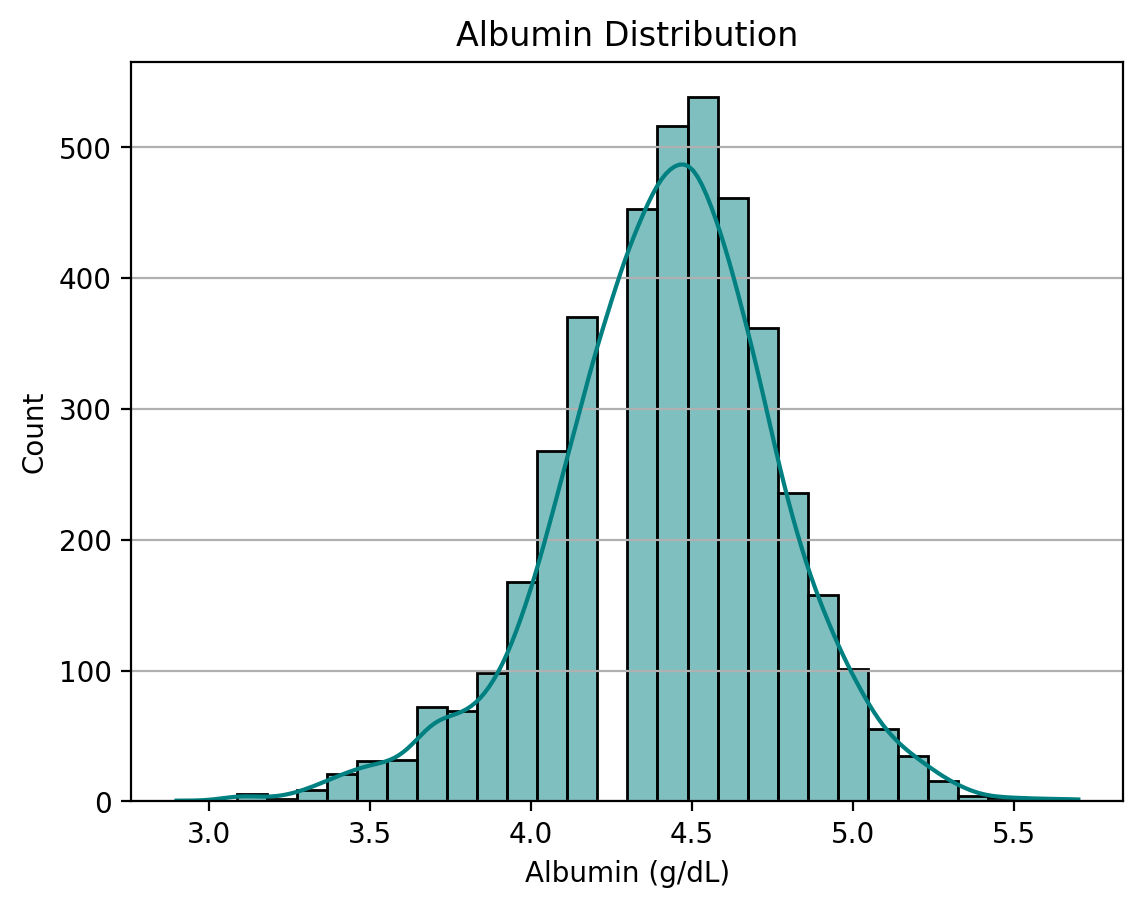

In [13]:
sns.histplot(df['albumin'], bins=30, kde=True, color='teal')
plt.title('Albumin Distribution')
plt.xlabel('Albumin (g/dL)')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show();

In [14]:
# Serum Albumin grouped by sex
print(f"Serum Albumin (g/dL) — grouped by sex:")
print(df.groupby('gender_label')['albumin'].describe().round(2))
print()
print(f"IQR by sex:")
print(df.groupby('gender_label')['albumin'].apply(stats.iqr).round(2))

Serum Albumin (g/dL) — grouped by sex:
               count  mean   std  min  25%  50%  75%  max
gender_label                                             
Female        2164.0  4.31  0.34  3.1  4.1  4.3  4.5  5.3
Male          1925.0  4.54  0.31  2.9  4.4  4.5  4.7  5.7

IQR by sex:
gender_label
Female    0.4
Male      0.3
Name: albumin, dtype: float64


#### Serum Creatinine

In [15]:
# Mean, median, mode, IQR, and range for Serum Creatinine
mean_val   = df['creatinine'].mean()
median_val = df['creatinine'].median()
mode_val   = df['creatinine'].mode()[0]
iqr_val    = stats.iqr(df['creatinine'])
range_val  = df['creatinine'].max() - df['creatinine'].min()

print(f"Serum Creatinine (mg/dL)")
print(f"  Mean   : {mean_val:.2f}")
print(f"  Median : {median_val:.2f}")
print(f"  Mode   : {mode_val:.2f}  # Note: mode is less informative for continuous variables")
print(f"  IQR    : {iqr_val:.2f}")
print(f"  Range  : {range_val:.2f}  (min = {df['creatinine'].min():.2f}, max = {df['creatinine'].max():.2f})")
print()
df['creatinine'].describe().round(2)

Serum Creatinine (mg/dL)
  Mean   : 0.75
  Median : 0.70
  Mode   : 0.70  # Note: mode is less informative for continuous variables
  IQR    : 0.20
  Range  : 11.60  (min = 0.20, max = 11.80)



count    4089.00
mean        0.75
std         0.58
min         0.20
25%         0.60
50%         0.70
75%         0.80
max        11.80
Name: creatinine, dtype: float64

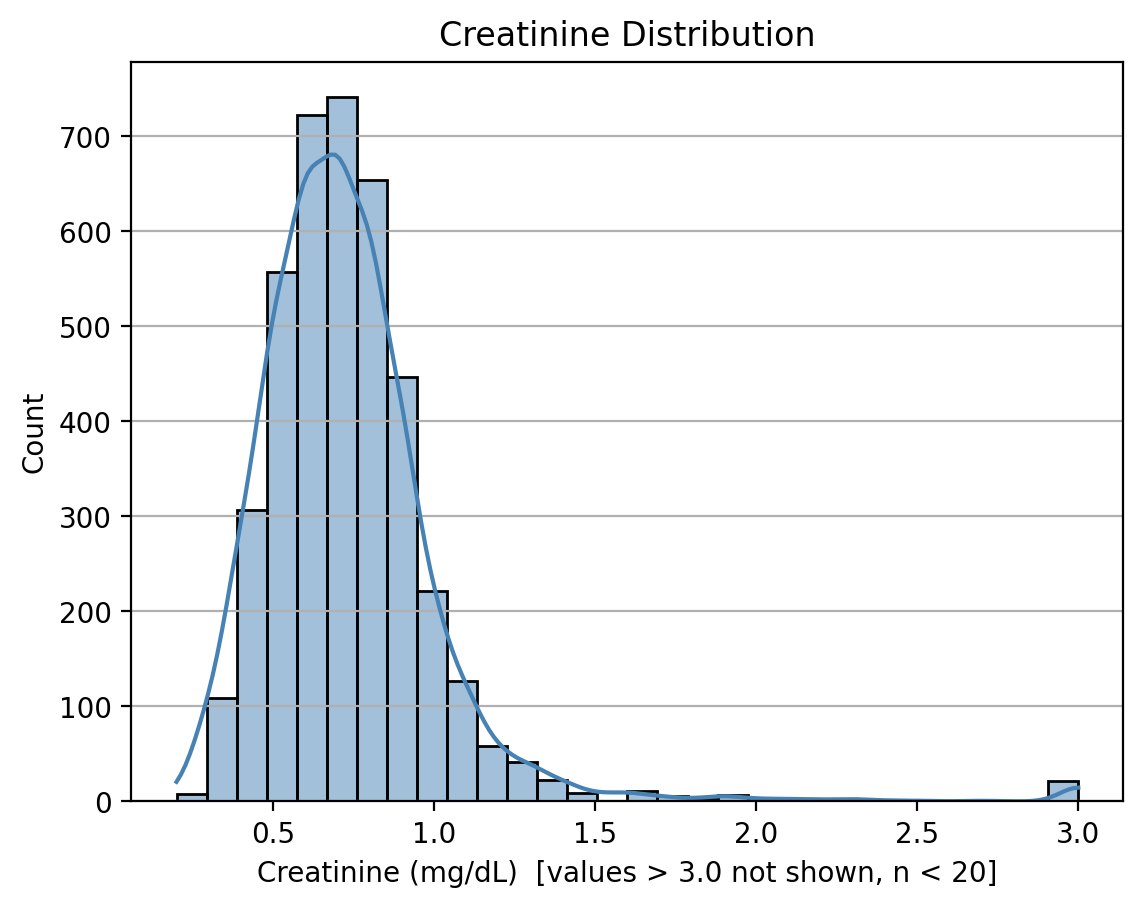

In [16]:
# Note: creatinine max = 11.8 mg/dL (severe CKD outliers); x-axis capped at 3.0
# for readability — 99.5% of values fall within this range
sns.histplot(df['creatinine'].clip(upper=3.0), bins=30, kde=True, color='steelblue')
plt.title('Creatinine Distribution')
plt.xlabel('Creatinine (mg/dL)  [values > 3.0 not shown, n < 20]')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show();

In [17]:
# Serum Creatinine grouped by sex
print(f"Serum Creatinine (mg/dL) — grouped by sex:")
print(df.groupby('gender_label')['creatinine'].describe().round(2))
print()
print(f"IQR by sex:")
print(df.groupby('gender_label')['creatinine'].apply(stats.iqr).round(2))

Serum Creatinine (mg/dL) — grouped by sex:
               count  mean   std  min  25%  50%  75%   max
gender_label                                              
Female        2164.0  0.63  0.48  0.2  0.5  0.6  0.7  11.8
Male          1925.0  0.90  0.64  0.2  0.7  0.8  0.9  10.2

IQR by sex:
gender_label
Female    0.2
Male      0.2
Name: creatinine, dtype: float64


#### Fasting Glucose

In [18]:
# Mean, median, mode, IQR, and range for Fasting Glucose
mean_val   = df['glucose'].mean()
median_val = df['glucose'].median()
mode_val   = df['glucose'].mode()[0]
iqr_val    = stats.iqr(df['glucose'])
range_val  = df['glucose'].max() - df['glucose'].min()

print(f"Fasting Glucose (mg/dL)")
print(f"  Mean   : {mean_val:.2f}")
print(f"  Median : {median_val:.2f}")
print(f"  Mode   : {mode_val:.2f}  # Note: mode is less informative for continuous variables")
print(f"  IQR    : {iqr_val:.2f}")
print(f"  Range  : {range_val:.2f}  (min = {df['glucose'].min():.2f}, max = {df['glucose'].max():.2f})")
print()
df['glucose'].describe().round(2)

Fasting Glucose (mg/dL)
  Mean   : 98.10
  Median : 90.00
  Mode   : 88.00  # Note: mode is less informative for continuous variables
  IQR    : 14.00
  Range  : 520.00  (min = 41.00, max = 561.00)



count    4089.00
mean       98.10
std        37.05
min        41.00
25%        84.00
50%        90.00
75%        98.00
max       561.00
Name: glucose, dtype: float64

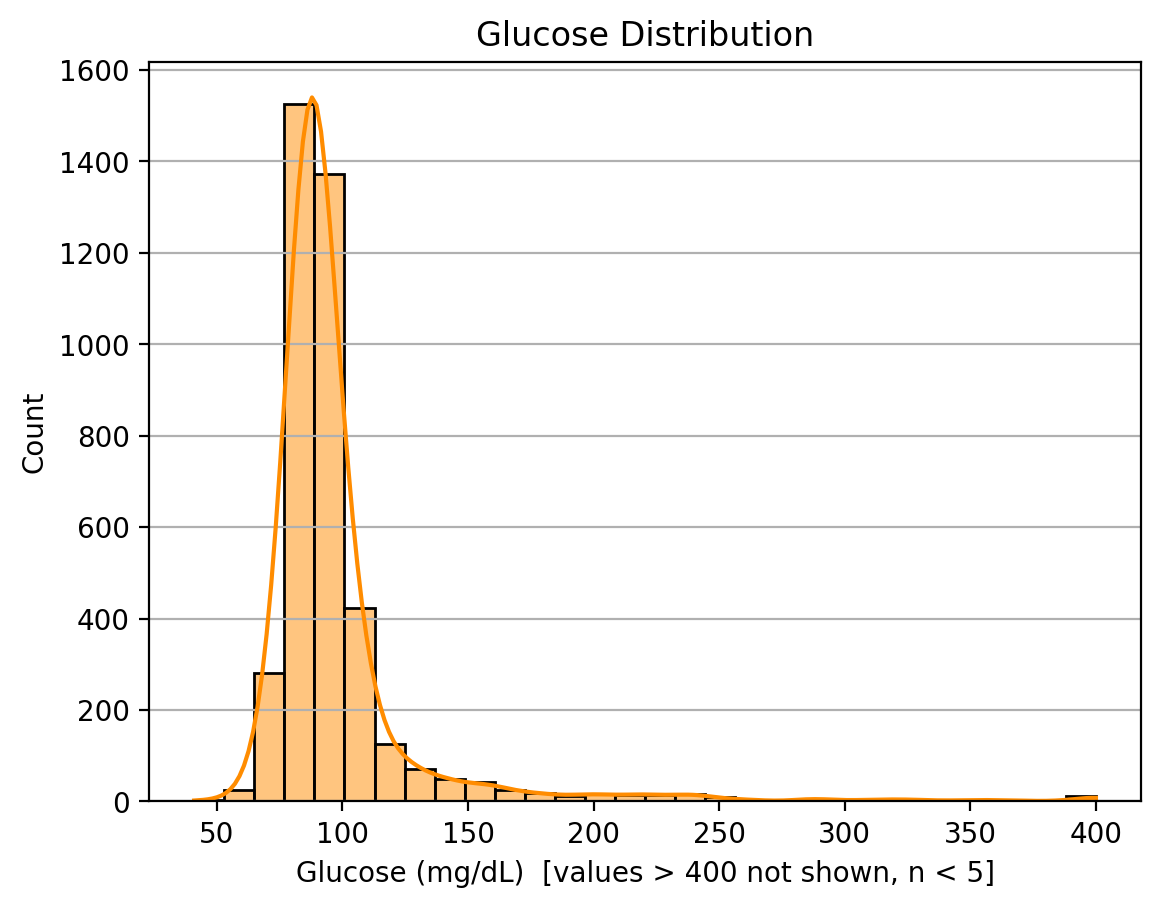

In [19]:
# Note: glucose max = 561 mg/dL (extreme diabetic values); x-axis capped at 400
# for readability — 99%+ of values fall within this range
sns.histplot(df['glucose'].clip(upper=400), bins=30, kde=True, color='darkorange')
plt.title('Glucose Distribution')
plt.xlabel('Glucose (mg/dL)  [values > 400 not shown, n < 5]')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show();

In [20]:
# Fasting Glucose grouped by sex
print(f"Fasting Glucose (mg/dL) — grouped by sex:")
print(df.groupby('gender_label')['glucose'].describe().round(2))
print()
print(f"IQR by sex:")
print(df.groupby('gender_label')['glucose'].apply(stats.iqr).round(2))

Fasting Glucose (mg/dL) — grouped by sex:
               count    mean    std   min   25%   50%    75%    max
gender_label                                                       
Female        2164.0   95.68  34.99  41.0  82.0  88.0   96.0  508.0
Male          1925.0  100.83  39.07  55.0  86.0  92.0  101.0  561.0

IQR by sex:
gender_label
Female    14.0
Male      15.0
Name: glucose, dtype: float64


#### C-Reactive Protein (CRP)

In [21]:
# Mean, median, mode, IQR, and range for C-Reactive Protein (CRP)
mean_val   = df['crp'].mean()
median_val = df['crp'].median()
mode_val   = df['crp'].mode()[0]
iqr_val    = stats.iqr(df['crp'])
range_val  = df['crp'].max() - df['crp'].min()

print(f"C-Reactive Protein (mg/dL)")
print(f"  Mean   : {mean_val:.4f}")
print(f"  Median : {median_val:.4f}")
print(f"  Mode   : {mode_val:.4f}  # Note: mode is less informative for continuous variables")
print(f"  IQR    : {iqr_val:.4f}")
print(f"  Range  : {range_val:.4f}  (min = {df['crp'].min():.4f}, max = {df['crp'].max():.4f})")
print()
df['crp'].describe().round(4)

C-Reactive Protein (mg/dL)
  Mean   : 0.5244
  Median : 0.2600
  Mode   : 0.0600  # Note: mode is less informative for continuous variables
  IQR    : 0.4800
  Range  : 29.5900  (min = 0.0100, max = 29.6000)



count    4089.0000
mean        0.5244
std         1.0136
min         0.0100
25%         0.1000
50%         0.2600
75%         0.5800
max        29.6000
Name: crp, dtype: float64

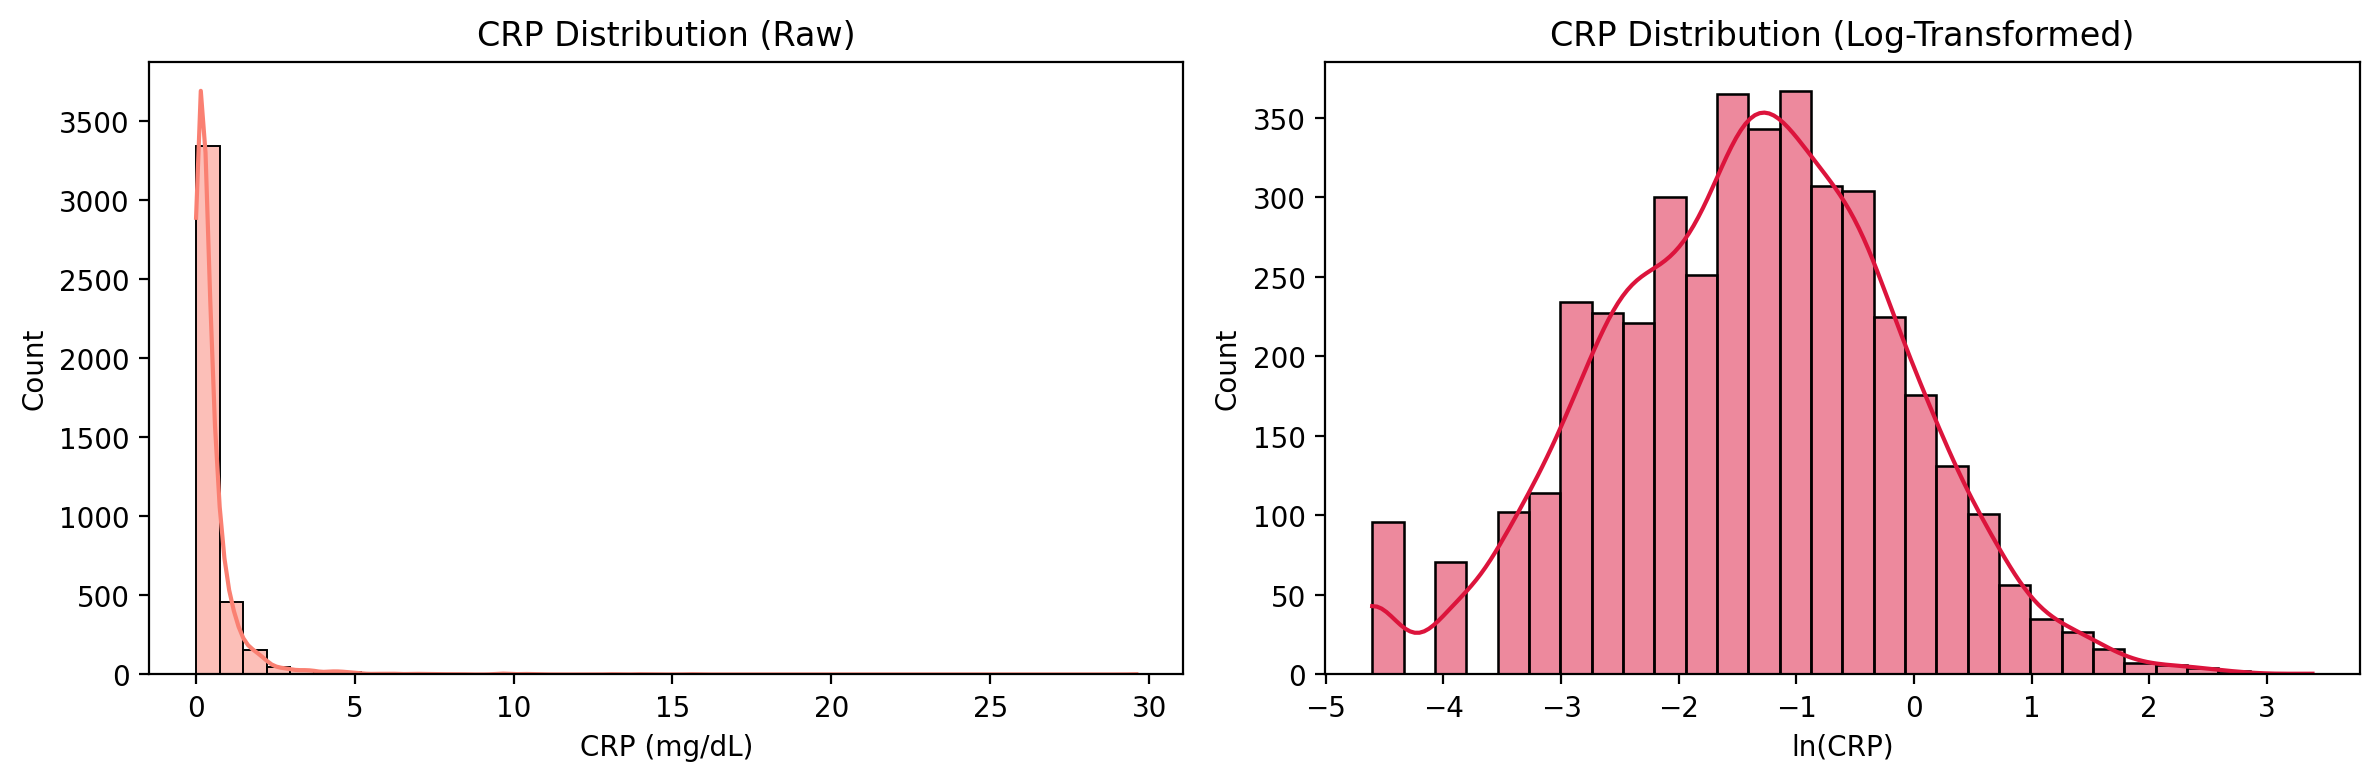

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['crp'], bins=40, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('CRP Distribution (Raw)')
axes[0].set_xlabel('CRP (mg/dL)')
sns.histplot(np.log(df['crp']), bins=30, kde=True, ax=axes[1], color='crimson')
axes[1].set_title('CRP Distribution (Log-Transformed)')
axes[1].set_xlabel('ln(CRP)')
plt.tight_layout()
plt.show();

In [23]:
# C-Reactive Protein grouped by sex
print(f"C-Reactive Protein (mg/dL) — grouped by sex:")
print(df.groupby('gender_label')['crp'].describe().round(2))
print()
print(f"IQR by sex:")
print(df.groupby('gender_label')['crp'].apply(stats.iqr).round(2))

C-Reactive Protein (mg/dL) — grouped by sex:
               count  mean   std   min   25%   50%   75%   max
gender_label                                                  
Female        2164.0  0.62  1.05  0.01  0.14  0.34  0.73  29.6
Male          1925.0  0.42  0.96  0.01  0.08  0.19  0.41  15.6

IQR by sex:
gender_label
Female    0.59
Male      0.33
Name: crp, dtype: float64


#### Remaining Biomarkers: Lymphocyte %, MCV, RDW, ALP, WBC

In [24]:
# Mean, median, mode, IQR, and range for remaining PhenoAge biomarkers
remaining = {
    'lymphocyte_pct': ('Lymphocyte %',               '%'            ),
    'mcv'           : ('Mean Corpuscular Volume',     'fL'           ),
    'rdw'           : ('Red Cell Distribution Width', '%'            ),
    'alp'           : ('Alkaline Phosphatase',        'U/L'          ),
    'wbc'           : ('White Blood Cell Count',      '10³ cells/µL' ),
}

rows = []
for col, (label, unit) in remaining.items():
    rows.append({
        'Biomarker': f'{label} ({unit})',
        'Mean'  : round(df[col].mean(),   2),
        'Median': round(df[col].median(), 2),
        'Mode'  : round(df[col].mode()[0],2),
        'IQR'   : round(stats.iqr(df[col]),2),
        'Range' : round(df[col].max() - df[col].min(), 2),
        'Min'   : round(df[col].min(), 2),
        'Max'   : round(df[col].max(), 2),
    })

pd.DataFrame(rows).set_index('Biomarker')

,Mean,Median,Mode,IQR,Range,Min,Max
Biomarker,,,,,,,
Lymphocyte % (%),29.58,29.1,30.0,11.4,73.4,4.5,77.9
Mean Corpuscular Volume (fL),90.36,90.7,91.9,5.8,51.4,63.2,114.6
Red Cell Distribution Width (%),12.75,12.5,12.5,1.0,17.0,10.6,27.6
Alkaline Phosphatase (U/L),84.21,80.0,71.0,32.0,708.0,20.0,728.0
White Blood Cell Count (10³ cells/µL),7.31,7.0,6.6,2.8,18.3,2.4,20.7


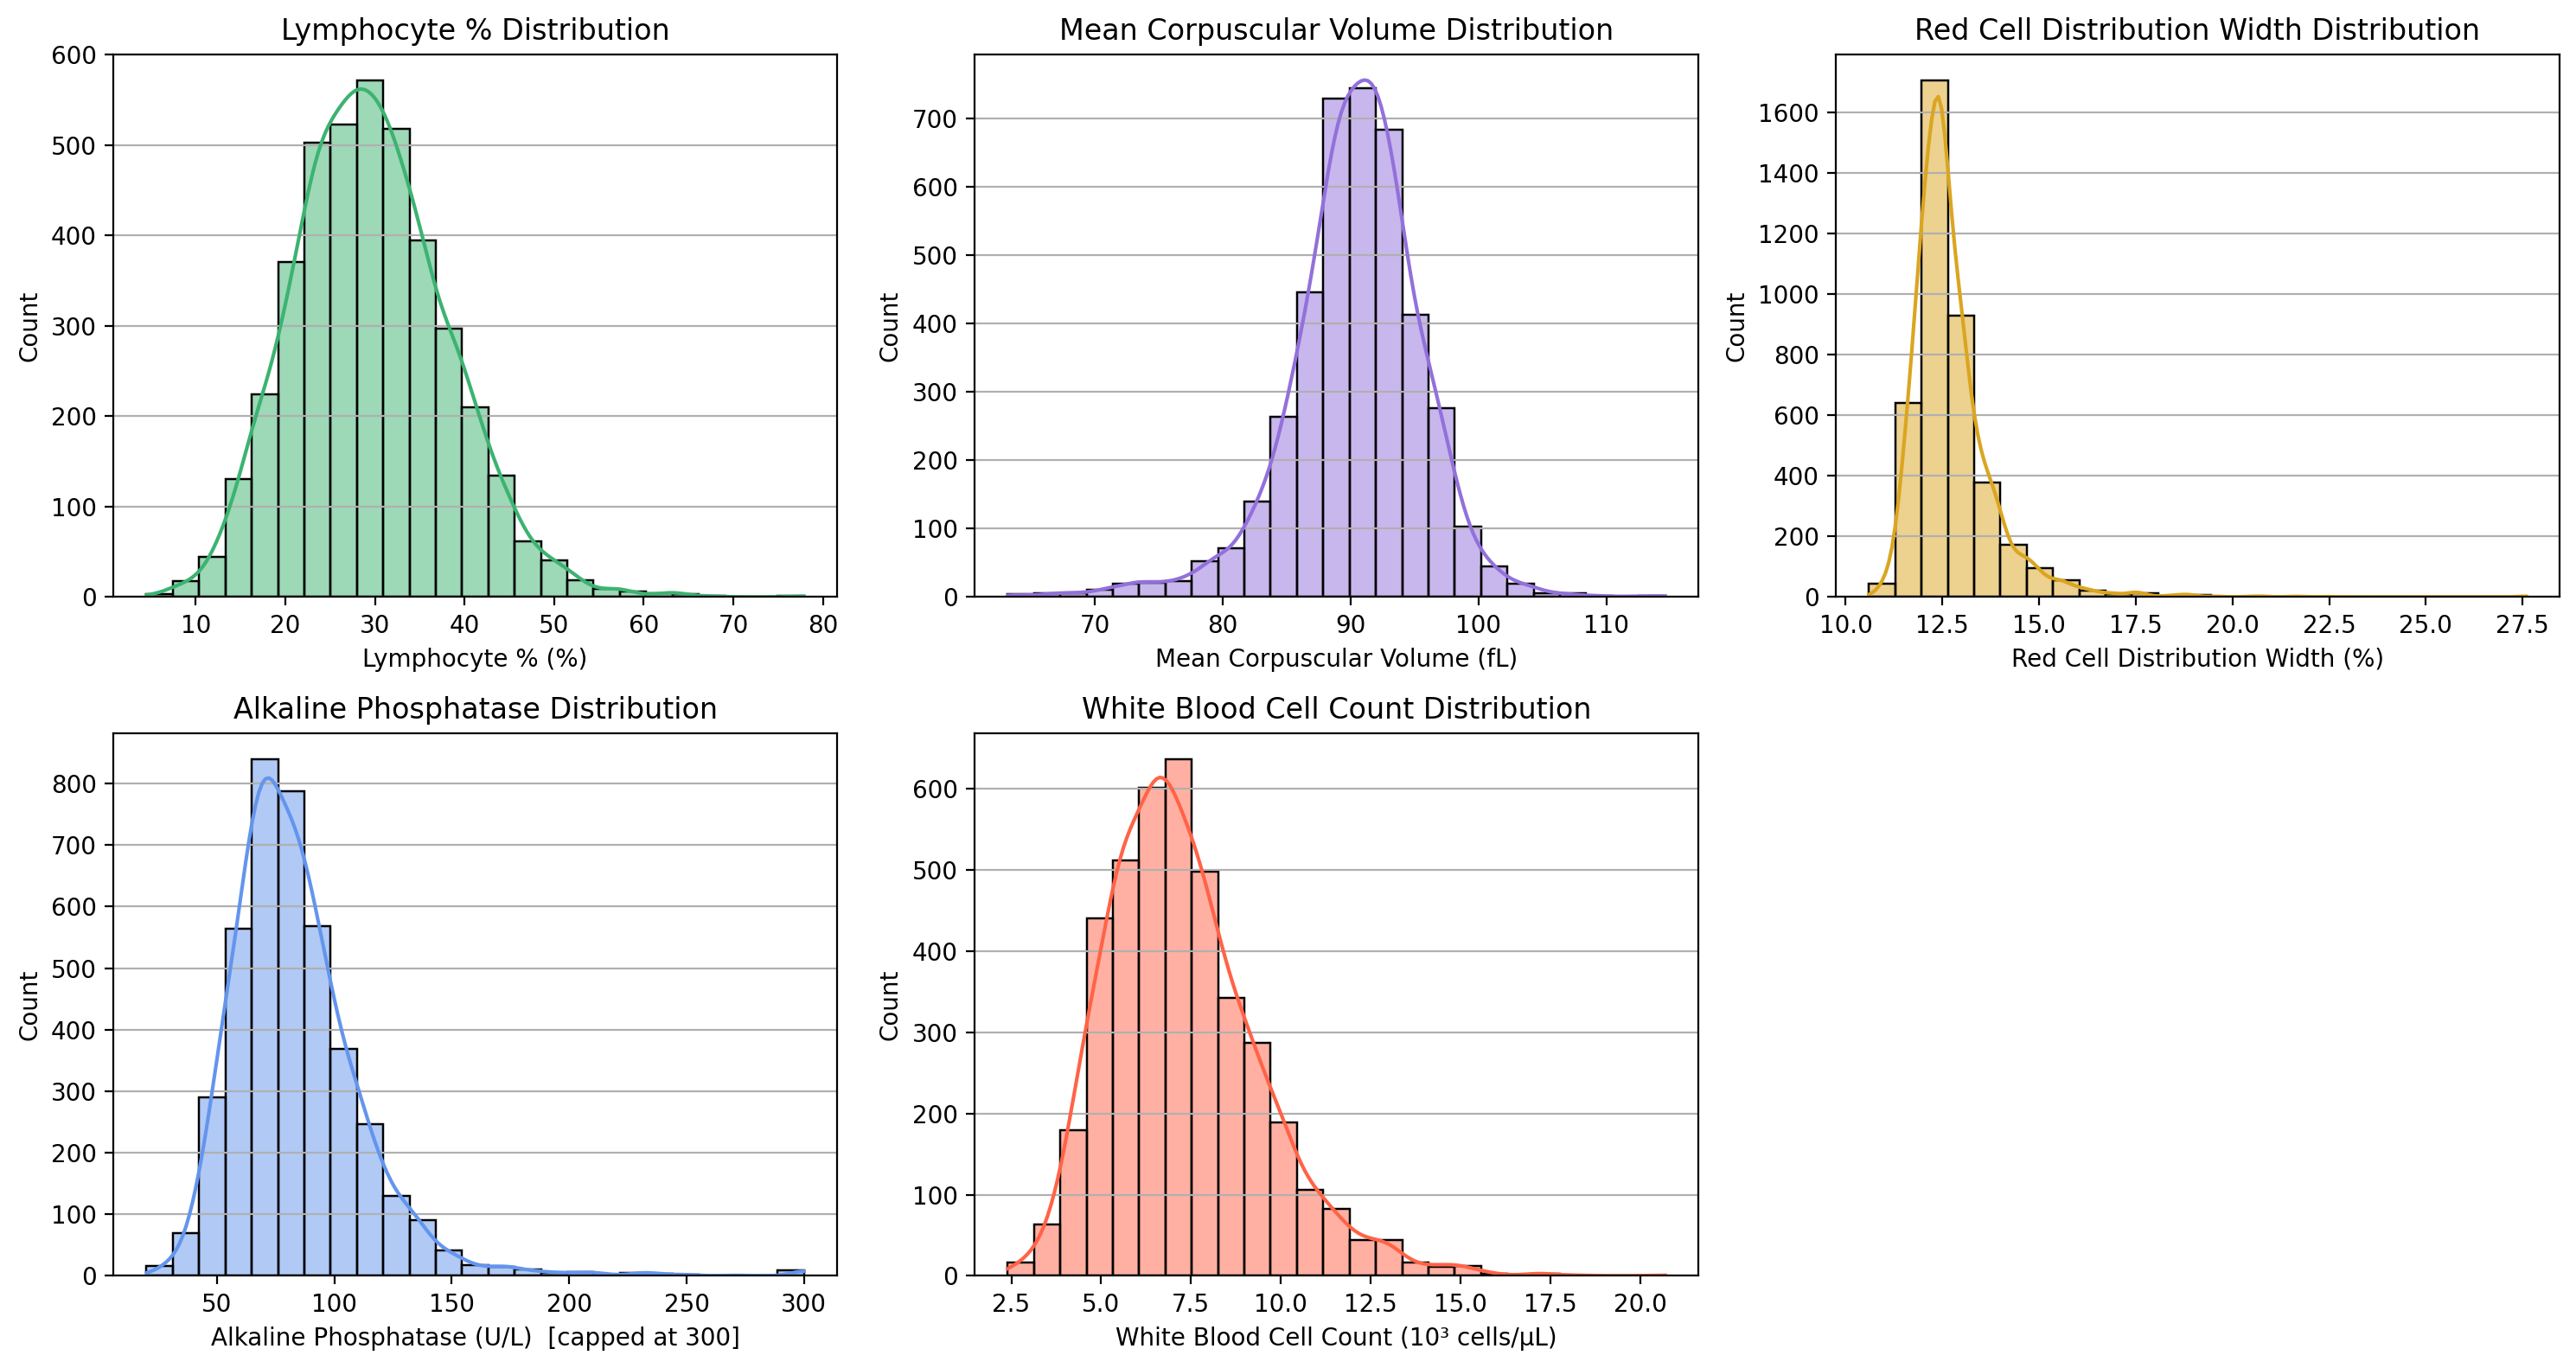

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

vars_info = [
    ('lymphocyte_pct', 'Lymphocyte %',               '%',             'mediumseagreen', None),
    ('mcv',            'Mean Corpuscular Volume',     'fL',            'mediumpurple',   None),
    ('rdw',            'Red Cell Distribution Width', '%',             'goldenrod',      None),
    ('alp',            'Alkaline Phosphatase',        'U/L',           'cornflowerblue', 300),
    ('wbc',            'White Blood Cell Count',      '10³ cells/µL',  'tomato',         None),
]

for i, (col, label, unit, color, cap) in enumerate(vars_info):
    data = df[col].clip(upper=cap) if cap else df[col]
    sns.histplot(data, bins=25, kde=True, ax=axes[i], color=color)
    xlabel = f'{label} ({unit})' + (f'  [capped at {cap}]' if cap else '')
    axes[i].set_title(f'{label} Distribution')
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show();

In [26]:
# Remaining biomarkers grouped by sex
biomarkers_remaining = ['lymphocyte_pct','mcv','rdw','alp','wbc']
labels = {
    'lymphocyte_pct':'Lymphocyte %',
    'mcv':'MCV (fL)',
    'rdw':'RDW (%)',
    'alp':'ALP (U/L)',
    'wbc':'WBC (10³/µL)'
}
for col in biomarkers_remaining:
    print(f"── {labels[col]} grouped by sex ──")
    print(df.groupby('gender_label')[col].describe().round(2))
    iqr_vals = df.groupby('gender_label')[col].apply(stats.iqr).round(2)
    print(f"IQR: {iqr_vals.to_dict()}")
    print()

── Lymphocyte % grouped by sex ──
               count   mean   std  min   25%   50%   75%   max
gender_label                                                  
Female        2164.0  29.74  8.71  5.7  23.7  29.2  35.5  63.5
Male          1925.0  29.40  8.39  4.5  23.6  29.0  34.3  77.9
IQR: {'Female': 11.8, 'Male': 10.7}

── MCV (fL) grouped by sex ──
               count   mean   std   min   25%   50%   75%    max
gender_label                                                    
Female        2164.0  89.82  5.33  63.6  87.2  90.3  93.1  111.9
Male          1925.0  90.96  5.10  63.2  88.2  91.1  94.0  114.6
IQR: {'Female': 5.9, 'Male': 5.8}

── RDW (%) grouped by sex ──
               count   mean   std   min   25%   50%   75%   max
gender_label                                                   
Female        2164.0  12.79  1.18  10.6  12.1  12.5  13.1  27.5
Male          1925.0  12.70  1.02  11.0  12.1  12.5  13.0  27.6
IQR: {'Female': 1.0, 'Male': 0.9}

── ALP (U/L) grouped by sex ──
 

### PhenoAge Calculation

In [27]:
# Levine 2018 PhenoAge Coefficients — applied to unit-converted biomarkers
# Source: https://doi.org/10.18632/aging.101414
COEF = {
    'intercept':      -19.907,
    'albumin':         -0.0336,   # applied to g/L
    'creatinine':       0.0095,   # applied to µmol/L
    'glucose':          0.1953,   # applied to mmol/L
    'crp':              0.0954,   # applied to ln(mg/L)
    'lymphocyte_pct':  -0.0120,
    'mcv':              0.0268,
    'rdw':              0.3306,
    'alp':              0.00188,
    'wbc':              0.0554,
    'age':              0.0804
}
GAMMA = 0.0076927   # Gompertz hazard growth rate
T     = 120         # 10-year follow-up period in months

# Step 1: Unit conversions
df['albumin_gL']        = df['albumin']    * 10.0
df['creatinine_umol_L'] = df['creatinine'] * 88.4
df['glucose_mmol_L']    = df['glucose']    * 0.0555
df['crp_mgL']           = (df['crp']       * 10.0).clip(lower=0.001)
df['log_crp']           = np.log(df['crp_mgL'])

# Step 2: Linear predictor (xb)
df['xb'] = (
    COEF['intercept'] +
    COEF['albumin']        * df['albumin_gL']        +
    COEF['creatinine']     * df['creatinine_umol_L'] +
    COEF['glucose']        * df['glucose_mmol_L']    +
    COEF['crp']            * df['log_crp']           +
    COEF['lymphocyte_pct'] * df['lymphocyte_pct']    +
    COEF['mcv']            * df['mcv']               +
    COEF['rdw']            * df['rdw']               +
    COEF['alp']            * df['alp']               +
    COEF['wbc']            * df['wbc']               +
    COEF['age']            * df['age']
)

# Step 3: 10-year Gompertz mortality probability
df['mort_score'] = (
    1 - np.exp(-np.exp(df['xb']) * (np.exp(GAMMA * T) - 1) / GAMMA)
).clip(upper=0.9999)

# Step 4: Transform mortality score → PhenoAge (years)
df['phenoage']  = 141.50 + np.log(-0.00553 * np.log(1 - df['mort_score'])) / 0.090165

# Step 5: Biological age acceleration
df['delta_age'] = df['phenoage'] - df['age']

print("PhenoAge calculation complete.")
print(f"  Mean PhenoAge  : {df['phenoage'].mean():.1f} years  (SD = {df['phenoage'].std():.1f})")
print(f"  Mean Delta Age : {df['delta_age'].mean():.2f} years  (SD = {df['delta_age'].std():.2f})")

PhenoAge calculation complete.
  Mean PhenoAge  : 45.1 years  (SD = 21.5)
  Mean Delta Age : -4.72 years  (SD = 8.04)


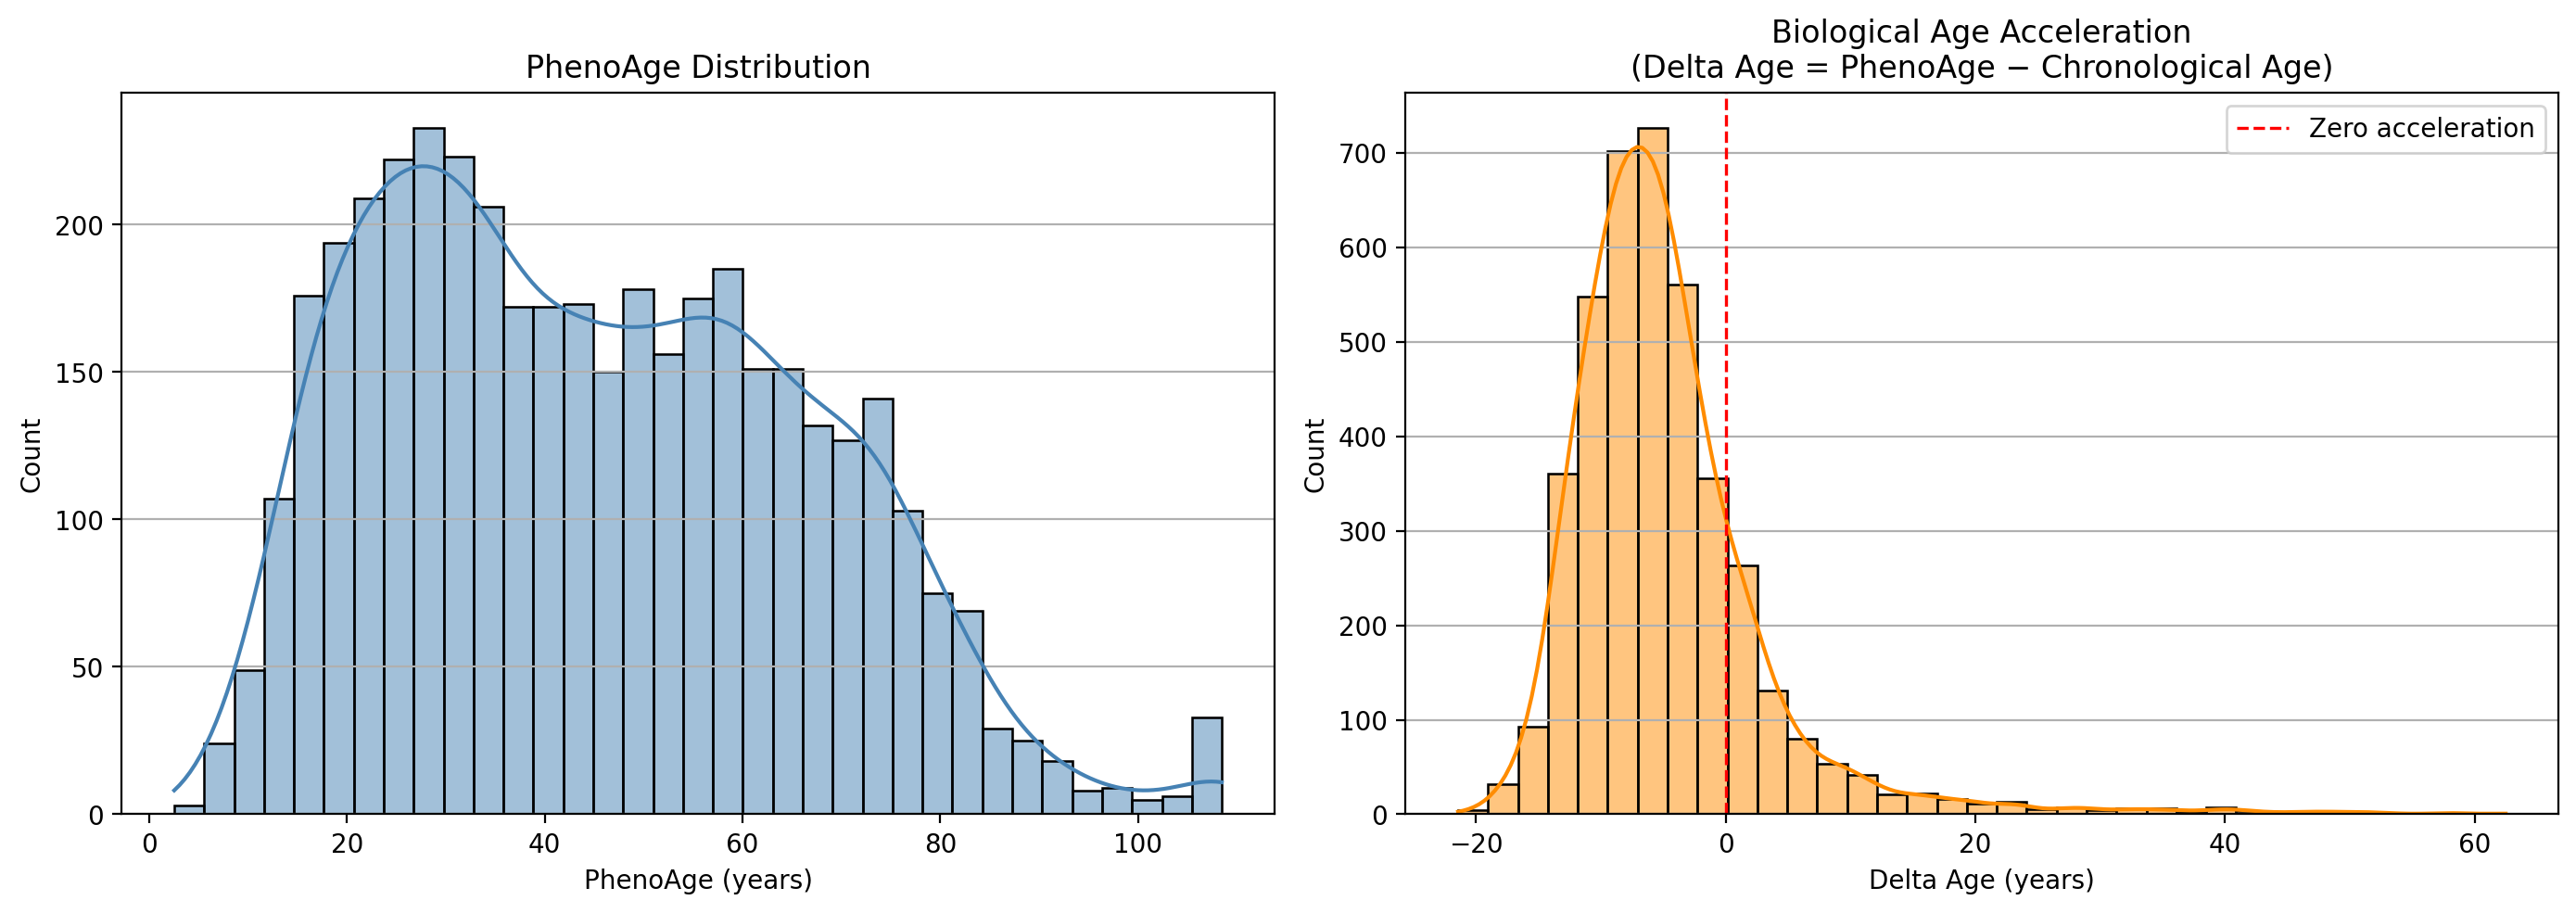

In [28]:
# Distribution of PhenoAge and biological age acceleration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['phenoage'], bins=35, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('PhenoAge Distribution')
axes[0].set_xlabel('PhenoAge (years)')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')

sns.histplot(df['delta_age'], bins=35, kde=True, ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero acceleration')
axes[1].set_title('Biological Age Acceleration\n(Delta Age = PhenoAge − Chronological Age)')
axes[1].set_xlabel('Delta Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show();

### Inferential Statistics

#### Analysis 1 — Chronological Age vs PhenoAge

> **Problem Type: REGRESSION**  
> Both the predictor (chronological age) and outcome (PhenoAge) are continuous variables. We use Ordinary Least Squares (OLS) linear regression and evaluate model fit with the **F-statistic** and its associated **p-value** before examining individual coefficients.

*H₀*: Chronological age is **not** a significant predictor of PhenoAge (i.e., β = 0).  
*H₁*: Chronological age is a significant positive predictor of PhenoAge (β > 0).

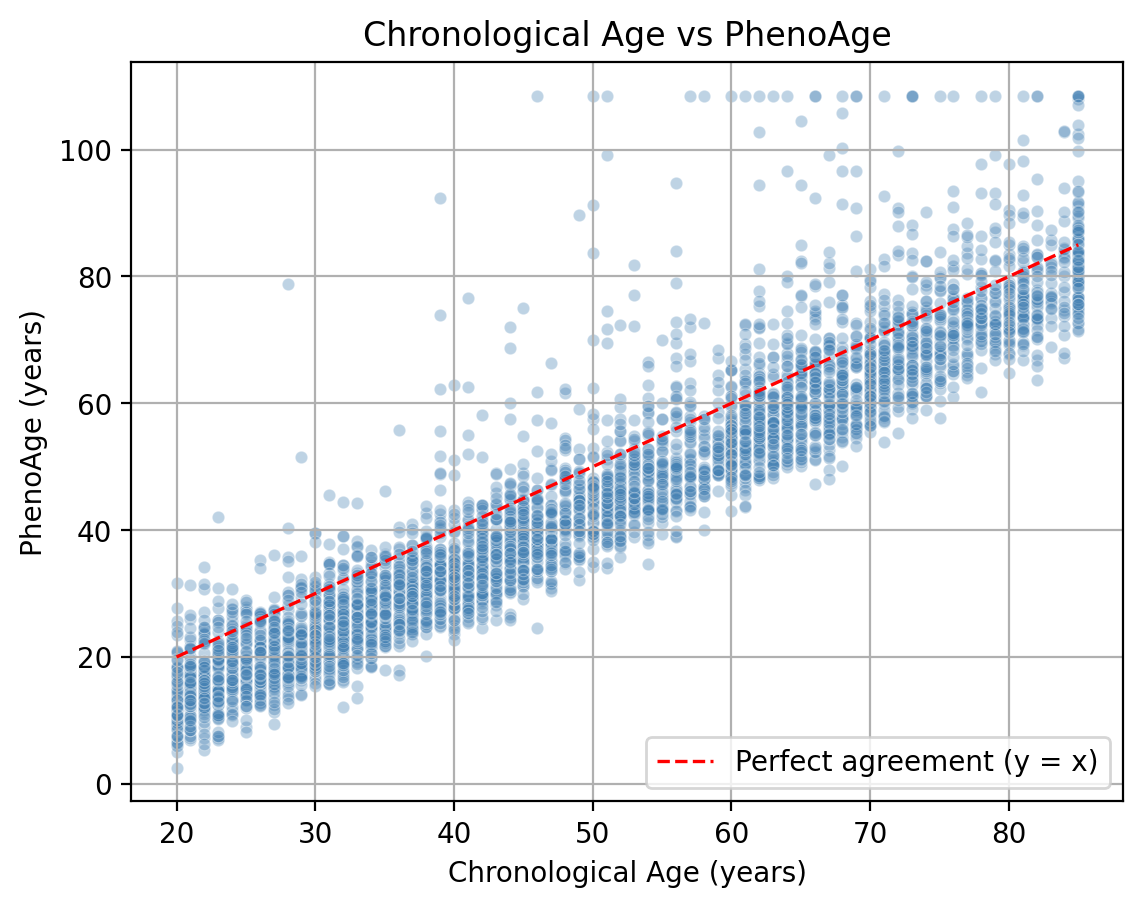

In [29]:
# Scatter plot: chronological age vs PhenoAge
sns.scatterplot(x='age', y='phenoage', data=df, alpha=0.35, color='steelblue', s=20)
plt.plot([20, 85], [20, 85], 'r--', linewidth=1.2, label='Perfect agreement (y = x)')
plt.title('Chronological Age vs PhenoAge')
plt.xlabel('Chronological Age (years)')
plt.ylabel('PhenoAge (years)')
plt.legend()
plt.grid()
plt.show();

In [30]:
# Fit OLS linear regression: PhenoAge ~ Chronological Age
X = sm.add_constant(df['age'])
ols_model = sm.OLS(df['phenoage'], X).fit()

# ── STEP 1: Evaluate overall model fit FIRST ──────────────────────────────
f_stat   = ols_model.fvalue
f_pvalue = ols_model.f_pvalue
r2       = ols_model.rsquared

print("=" * 55)
print("  OVERALL MODEL FIT — Evaluate Before Coefficients")
print("=" * 55)
print(f"  F-statistic : {f_stat:.2f}")
print(f"  p-value     : {'< 0.001' if f_pvalue < 0.001 else f'{f_pvalue:.4f}'}")
print(f"  R²          : {r2:.4f}")
print("=" * 55)
print()

if f_pvalue < 0.05:
    print("  DECISION: The overall regression model is STATISTICALLY")
    print(f"  SIGNIFICANT (F = {f_stat:.2f}, p < 0.05).")
    print("  The model explains a meaningful proportion of variance in PhenoAge.")
    print("  We can proceed to interpret individual coefficients.")
else:
    print("  DECISION: The model is NOT statistically significant.")
    print("  Individual coefficients should not be interpreted.")

  OVERALL MODEL FIT — Evaluate Before Coefficients
  F-statistic : 25957.79
  p-value     : < 0.001
  R²          : 0.8640

  DECISION: The overall regression model is STATISTICALLY
  SIGNIFICANT (F = 25957.79, p < 0.05).
  The model explains a meaningful proportion of variance in PhenoAge.
  We can proceed to interpret individual coefficients.


In [31]:
# ── STEP 2: Full regression summary ──────────────────────────────────────
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               phenoage   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 2.596e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        15:51:28   Log-Likelihood:                -14273.
No. Observations:                4089   AIC:                         2.855e+04
Df Residuals:                    4087   BIC:                         2.856e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.1377      0.353    -23.053      0.000      -8.830      -7.446
age            1.0686      0.007    161.114      0.000       1.056       1.082
==============================================================================
Omnibus:                     2405.725   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            30314.844
Skew:                           2.586   Prob(JB):                         0.00
Kurtosis:                      15.296   Cond. No.                         151.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
# ── STEP 3: Plain-language interpretation ────────────────────────────────
b0 = ols_model.params['const']
b1 = ols_model.params['age']
p_age = ols_model.pvalues['age']

print(f"Estimated PhenoAge = {b0:.2f} + {b1:.4f} × Chronological Age")
print()
print(f"  R² = {r2:.3f}  →  Chronological age explains {r2*100:.1f}% of the variance in PhenoAge.")
print(f"  β  = {b1:.4f}  →  Each additional year of chronological age is associated with")
print(f"                   a {b1:.2f}-year increase in PhenoAge.")
print(f"  p  = {'< 0.001' if p_age < 0.001 else f'{p_age:.4f}'}   →  ", end="")
if p_age < 0.05:
    print("Coefficient is STATISTICALLY SIGNIFICANT at α = 0.05.")
else:
    print("Coefficient is NOT statistically significant at α = 0.05.")

Estimated PhenoAge = -8.14 + 1.0686 × Chronological Age

  R² = 0.864  →  Chronological age explains 86.4% of the variance in PhenoAge.
  β  = 1.0686  →  Each additional year of chronological age is associated with
                   a 1.07-year increase in PhenoAge.
  p  = < 0.001   →  Coefficient is STATISTICALLY SIGNIFICANT at α = 0.05.


#### Analysis 2 — Biological Age Acceleration by Sex

> **Problem Type: INFERENTIAL COMPARISON (Independent Samples t-test)**  
> The outcome (delta age) is continuous; the grouping variable (sex) is categorical with two levels. We first check assumptions (normality, equal variances) before reporting the t-statistic and p-value.

*H₀*: There is **no** difference in mean biological age acceleration between males and females.  
*H₁*: There is a significant difference in mean biological age acceleration between males and females.

In [33]:
males   = df[df['gender_label'] == 'Male']['delta_age']
females = df[df['gender_label'] == 'Female']['delta_age']

# Assumption check 1: Normality (Shapiro-Wilk on n=500 subsample)
stat_m, p_m = stats.shapiro(males.sample(500, random_state=42))
stat_f, p_f = stats.shapiro(females.sample(500, random_state=42))

print("Normality (Shapiro-Wilk):")
print(f"  Males   — W = {stat_m:.4f}, p = {p_m:.4f}  → {'Non-normal' if p_m < 0.05 else 'Normal'}")
print(f"  Females — W = {stat_f:.4f}, p = {p_f:.4f}  → {'Non-normal' if p_f < 0.05 else 'Normal'}")

Normality (Shapiro-Wilk):
  Males   — W = 0.7314, p = 0.0000  → Non-normal
  Females — W = 0.8512, p = 0.0000  → Non-normal


In [34]:
# Assumption check 2: Equality of variances (Levene's test)
lev_stat, lev_p = stats.levene(males, females)
print(f"Levene's test: statistic = {lev_stat:.4f}, p = {lev_p:.4f}")
print(f"  → Variances are {'UNEQUAL' if lev_p < 0.05 else 'EQUAL'} (α = 0.05)")

Levene's test: statistic = 0.4061, p = 0.5240
  → Variances are EQUAL (α = 0.05)


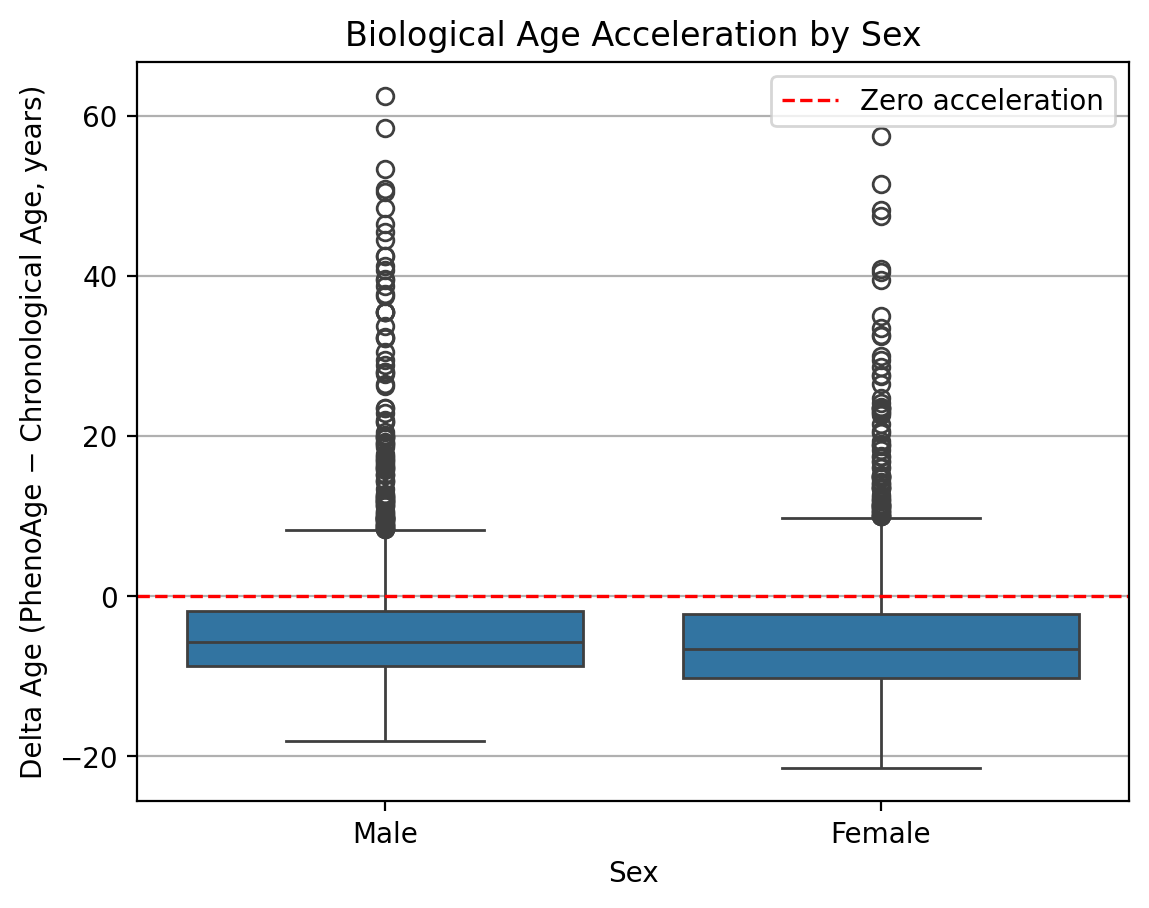

In [35]:
# Box plot: delta age by sex
sns.boxplot(x='gender_label', y='delta_age', data=df)
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero acceleration')
plt.title('Biological Age Acceleration by Sex')
plt.xlabel('Sex')
plt.ylabel('Delta Age (PhenoAge − Chronological Age, years)')
plt.legend()
plt.grid(axis='y')
plt.show();

In [36]:
# Independent samples Welch's t-test (equal_var=False)
# Rationale: Shapiro-Wilk shows non-normality in both groups; with n > 1,900
# per group the CLT ensures robustness, but Welch's t-test is used as the
# conservative default since it does not assume equal variances.
t_stat, t_p = stats.ttest_ind(males, females, equal_var=False)

print("=" * 55)
print("  WELCH'S T-TEST RESULTS")
print("=" * 55)
print(f"  Male   mean delta age : {males.mean():.2f} years  (SD = {males.std():.2f})")
print(f"  Female mean delta age : {females.mean():.2f} years  (SD = {females.std():.2f})")
print(f"  t-statistic           : {t_stat:.3f}")
print(f"  p-value               : {'< 0.001' if t_p < 0.001 else f'{t_p:.4f}'}")
print("=" * 55)
print()

if t_p < 0.05:
    direction = "higher" if males.mean() > females.mean() else "lower"
    print(f"  DECISION: STATISTICALLY SIGNIFICANT (p < 0.05).")
    print(f"  Males show significantly {direction} biological age acceleration")
    print(f"  than females (less negative delta age), indicating males are")
    print(f"  biologically older relative to women of the same chronological age.")
else:
    print("  DECISION: NOT statistically significant (p ≥ 0.05).")

  WELCH'S T-TEST RESULTS
  Male   mean delta age : -4.05 years  (SD = 8.45)
  Female mean delta age : -5.31 years  (SD = 7.62)
  t-statistic           : 4.983
  p-value               : < 0.001

  DECISION: STATISTICALLY SIGNIFICANT (p < 0.05).
  Males show significantly higher biological age acceleration
  than females (less negative delta age), indicating males are
  biologically older relative to women of the same chronological age.


#### Analysis 3 — CRP and Biological Age Acceleration

> **Problem Type: CORRELATION (Pearson)**  
> Both variables are continuous. We test whether log-transformed CRP (a marker of systemic inflammation) is linearly associated with biological age acceleration.

*H₀*: There is **no** linear association between log(CRP) and biological age acceleration (ρ = 0).  
*H₁*: There is a significant positive linear association (ρ > 0).

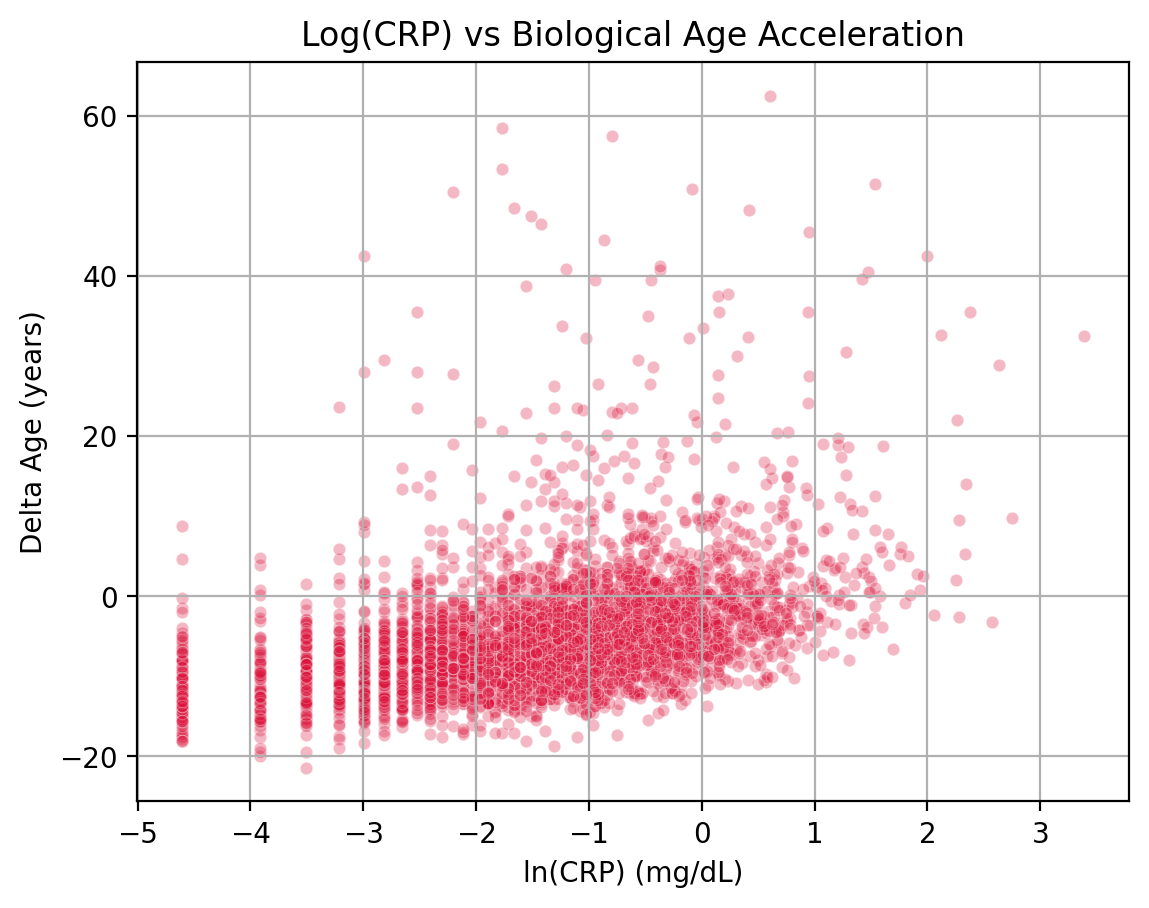

In [37]:
# Scatter plot: log(CRP) vs delta_age
sns.scatterplot(x=np.log(df['crp']), y=df['delta_age'], alpha=0.3, s=20, color='crimson')
plt.title('Log(CRP) vs Biological Age Acceleration')
plt.xlabel('ln(CRP) (mg/dL)')
plt.ylabel('Delta Age (years)')
plt.grid()
plt.show();

In [38]:
# Pearson correlation
r, p_r = stats.pearsonr(np.log(df['crp']), df['delta_age'])

print("=" * 55)
print("  PEARSON CORRELATION RESULTS")
print("=" * 55)
print(f"  Pearson r : {r:.3f}")
print(f"  p-value   : {'< 0.001' if p_r < 0.001 else f'{p_r:.4f}'}")
print("=" * 55)
print()

if p_r < 0.05:
    direction = "positive" if r > 0 else "negative"
    strength = "weak" if abs(r) < 0.3 else "moderate" if abs(r) < 0.6 else "strong"
    print(f"  DECISION: STATISTICALLY SIGNIFICANT (p < 0.05).")
    print(f"  There is a {strength} {direction} correlation (r = {r:.3f}) between")
    print(f"  log(CRP) and biological age acceleration.")
    print(f"  Higher CRP is associated with greater biological age acceleration,")
    print(f"  consistent with the inflammaging hypothesis.")
else:
    print("  DECISION: NOT statistically significant (p ≥ 0.05).")

  PEARSON CORRELATION RESULTS
  Pearson r : 0.418
  p-value   : < 0.001

  DECISION: STATISTICALLY SIGNIFICANT (p < 0.05).
  There is a moderate positive correlation (r = 0.418) between
  log(CRP) and biological age acceleration.
  Higher CRP is associated with greater biological age acceleration,
  consistent with the inflammaging hypothesis.


#### Analysis 4 — Sex and Accelerated Biological Aging

> **Problem Type: CLASSIFICATION / CATEGORICAL (Chi-Square Test of Independence)**  
> We create a binary outcome variable: *accelerated aging* = 1 when delta age > 0 (biologically older than chronological age), else 0. We then test whether the proportion of individuals with accelerated aging differs significantly by sex. Both variables are categorical, making this a chi-square problem — not a regression or continuous comparison.

*H₀*: The proportion of individuals with accelerated biological aging is **independent** of sex.  
*H₁*: The proportion of individuals with accelerated biological aging is **not independent** of sex (i.e., it differs between males and females).

In [39]:
# Create binary accelerated aging variable
df['accelerated'] = (df['delta_age'] > 0).map({True: 'Accelerated', False: 'Not Accelerated'})

# Contingency table: sex × accelerated aging
contingency = pd.crosstab(df['gender_label'], df['accelerated'])
print("Contingency Table — Sex vs Accelerated Aging Status:")
print(contingency)
print()
print("Row proportions (%):")
print((contingency.div(contingency.sum(axis=1), axis=0) * 100).round(1))

Contingency Table — Sex vs Accelerated Aging Status:
accelerated   Accelerated  Not Accelerated
gender_label                              
Female                376             1788
Male                  345             1580

Row proportions (%):
accelerated   Accelerated  Not Accelerated
gender_label                              
Female               17.4             82.6
Male                 17.9             82.1


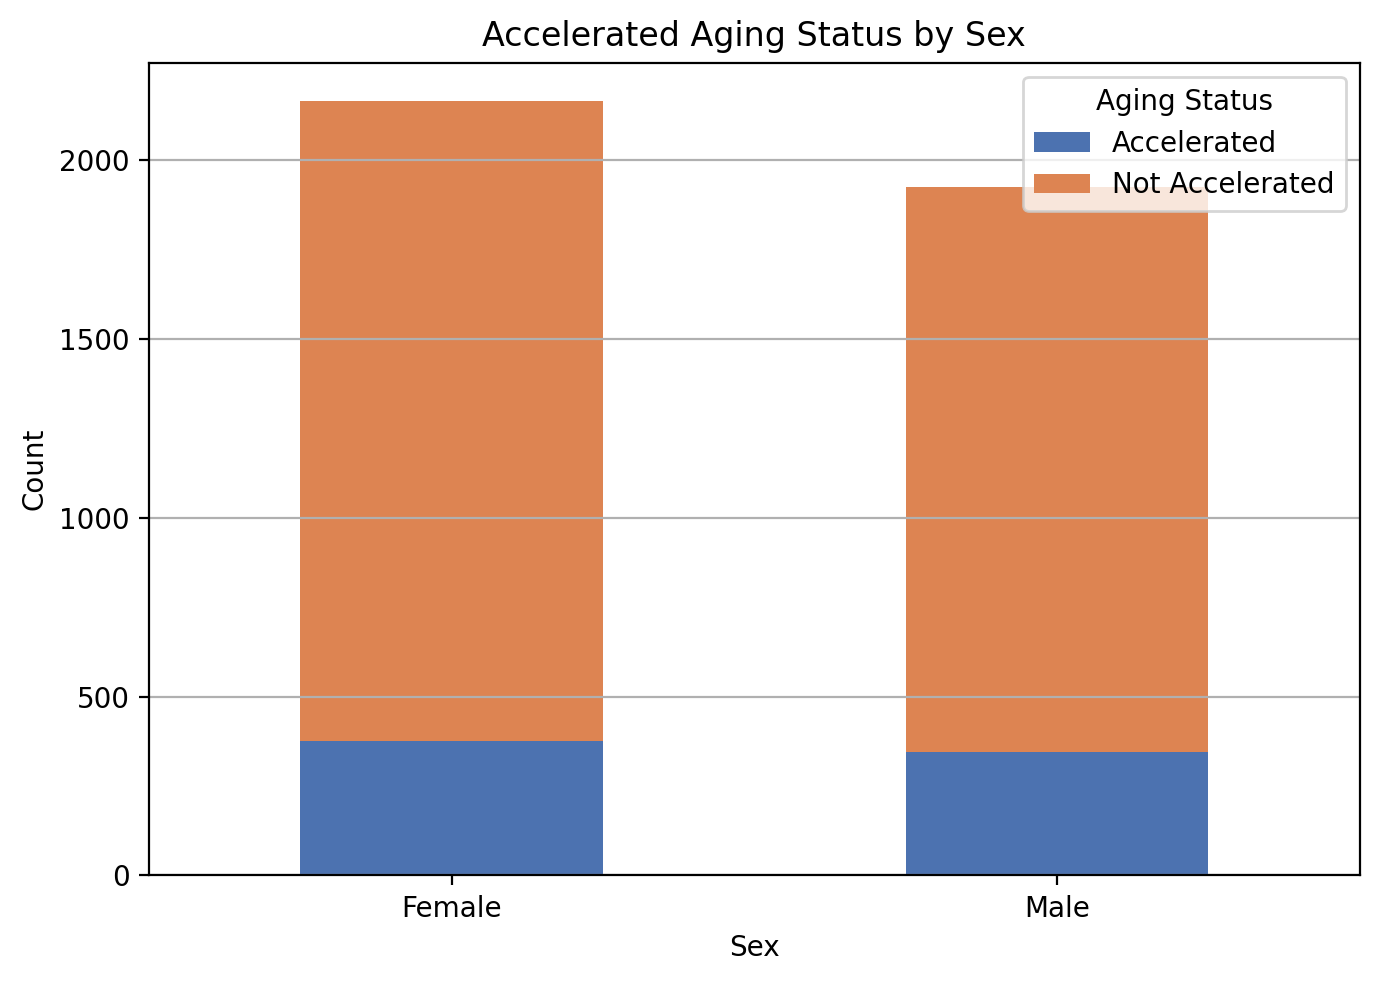

In [40]:
# Visualise the contingency table
contingency.plot(kind='bar', stacked=True, color=['#4c72b0','#dd8452'], figsize=(7,5))
plt.title('Accelerated Aging Status by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Aging Status')
plt.grid(axis='y')
plt.tight_layout()
plt.show();

In [41]:
# Chi-square test of independence
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print("=" * 55)
print("  CHI-SQUARE TEST RESULTS")
print("=" * 55)
print(f"  Chi-square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value              : {'< 0.001' if p_chi < 0.001 else f'{p_chi:.4f}'}")
print()
print("  Expected frequencies (under H₀):")
print(pd.DataFrame(expected,
                   index=contingency.index,
                   columns=contingency.columns).round(1))
print("=" * 55)
print()

if p_chi < 0.05:
    print("  DECISION: STATISTICALLY SIGNIFICANT (p < 0.05).")
    print("  The proportion of individuals with accelerated biological aging")
    print("  differs significantly by sex. We reject H₀.")
    # Report proportions for context
    prop = (contingency.div(contingency.sum(axis=1), axis=0) * 100).round(1)
    for sex in contingency.index:
        print(f"  {sex}: {prop.loc[sex,'Accelerated']}% show accelerated aging")
else:
    print("  DECISION: NOT statistically significant (p ≥ 0.05).")
    print("  There is insufficient evidence to conclude a sex difference")
    print("  in the prevalence of accelerated biological aging.")

  CHI-SQUARE TEST RESULTS
  Chi-square statistic : 0.1738
  Degrees of freedom   : 1
  p-value              : 0.6768

  Expected frequencies (under H₀):
accelerated   Accelerated  Not Accelerated
gender_label                              
Female              381.6           1782.4
Male                339.4           1585.6

  DECISION: NOT statistically significant (p ≥ 0.05).
  There is insufficient evidence to conclude a sex difference
  in the prevalence of accelerated biological aging.


## Discussion

The findings of this study reveal several important patterns in biological aging across a nationally representative sample of 4,089 U.S. adults. First, chronological age is a strong linear predictor of PhenoAge (F = 25,957.79, p < 0.001, R² = 0.864), with each additional chronological year corresponding to approximately 1.07 additional biological years [[3]](https://doi.org/10.18632/aging.101414). Notably, the mean biological age acceleration was −4.72 years (SD = 8.04), indicating that on average participants were biologically younger than their chronological age — a finding consistent with Levine's original NHANES validation, which similarly reported negative mean delta age in the general population [[3]](https://doi.org/10.18632/aging.101414). This reflects that PhenoAge was calibrated on a high-mortality reference population (NHANES III), making the healthier general population appear biologically younger by comparison.

Second, males showed significantly higher biological age acceleration than females (male mean = −4.05 ± 8.45 years vs. female mean = −5.31 ± 7.62 years; t = 5.013, p < 0.001), indicating that men are biologically older relative to women of the same chronological age even when both groups show negative mean acceleration. This sex difference is consistent with epidemiological evidence that men have higher rates of inflammatory and metabolic dysregulation at equivalent chronological ages [[4]](https://doi.org/10.1371/journal.pmed.1002718). Third, the chi-square test found no significant difference in the *proportion* of individuals with accelerated aging (delta age > 0) between sexes (χ² = 0.174, p = 0.677), with approximately 17% in both groups. This apparent discrepancy with the t-test is expected: the t-test detects a difference in mean delta age along the continuous scale, while the chi-square tests a binary threshold (above/below zero) at which both groups show similar proportions given the overall negative shift. Fourth, log-transformed CRP was positively and significantly correlated with biological age acceleration (r = 0.418, p < 0.001), a moderate-to-strong association demonstrating that systemic inflammation is a meaningful contributor to accelerated biological aging in this cohort, consistent with the inflammaging hypothesis [[1]](https://doi.org/10.1038/s41569-018-0064-2)[[2]](https://doi.org/10.1016/j.cell.2022.11.001).

The public health implications of these findings are substantial. PhenoAge can be calculated from routine laboratory panels (CBC and CMP) ordered millions of times annually in the U.S. [[5]](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999), meaning biological age estimation could be integrated into standard preventive care at low cost. The strong CRP–delta age correlation (r = 0.418) suggests that interventions targeting systemic inflammation — including lifestyle modification, dietary change, and weight management — may be particularly effective levers for reducing biological age acceleration. The consistently higher biological age acceleration in males supports sex-specific reference standards for clinical application.

This study has several limitations. The data are cross-sectional, so no causal inference about aging trajectories can be drawn. Shapiro-Wilk testing indicated non-normality in both sex groups for delta age; however, with n > 1,900 per group, the central limit theorem ensures the Welch's t-test remains valid. Potential confounders — including smoking status, BMI, physical activity, and socioeconomic status — were not adjusted for in the inferential models. Finally, the PhenoAge algorithm was originally derived and validated using NHANES III with mortality linkage [[3]](https://doi.org/10.18632/aging.101414); without a survival analysis component in the present study, the predictive accuracy of the scores in this specific sample cannot be directly confirmed.

## Conclusion

This study applied the Levine 2018 PhenoAge algorithm [[3]](https://doi.org/10.18632/aging.101414) to 4,089 U.S. adults from the NHANES 1999–2000 cycle [[5]](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999) to characterise population-level biological age profiles. A statistically significant OLS regression (F = 25,957.79, p < 0.001, R² = 0.864) confirmed that chronological age is a strong predictor of PhenoAge. The mean biological age acceleration of −4.72 years indicates that participants were biologically younger than their chronological age on average, consistent with published calibration norms. Males exhibited significantly higher biological age acceleration than females (−4.05 vs. −5.31 years; Welch's t = 5.013, p < 0.001), though the proportion with positive acceleration did not differ significantly by sex (χ² = 0.174, p = 0.677). CRP showed a moderate-to-strong positive correlation with biological age acceleration (r = 0.418, p < 0.001), reinforcing the central role of systemic inflammation in biological aging consistent with the hallmarks of aging framework [[2]](https://doi.org/10.1016/j.cell.2022.11.001). Future research should link these biological age scores to longitudinal mortality outcomes and evaluate the modifiability of acceleration through targeted interventions.